# Detecção de Discurso de Ódio em Português com BERT — ToLD-BR

Este notebook aplica o modelo pré-treinado **BERTimbau** (`neuralmind/bert-base-portuguese-cased`) à base **ToLD-BR**.

**Configurações padronizadas:**
- Dataset: ToLD-BR (carregado via GitHub)
- Split: 80% treino / 20% teste, com `stratify=y` e `random_state=42`
- Binarização: qualquer pontuação ofensiva ≥ 1 em qualquer categoria → ofensivo
- Pré-processamento: não aplicado (BERT usa tokenizador WordPiece nativo)
- Métrica principal: F1-score macro

## 1. Importações

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print('PyTorch version:', torch.__version__)
print('GPU disponível:', torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Usando:', device)

/home/heliocm/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-19 01:05:21.065001: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PyTorch version: 2.7.1+cu126
GPU disponível: False
Usando: cpu


## 2. Carregamento da base de dados

In [2]:
url = 'https://raw.githubusercontent.com/JAugusto97/ToLD-Br/main/ToLD-BR.csv'
df = pd.read_csv(url)

print(f'Total de amostras: {len(df)}')
df.head()

Total de amostras: 21000


,text,homophobia,obscene,insult,racism,misogyny,xenophobia
0,Meu nivel de amizade com isis é ela ter meu in...,0.0,0.0,2.0,0.0,0.0,0.0
1,"rt @user @user o cara adultera dados, que fora...",0.0,0.0,1.0,0.0,0.0,0.0
2,@user @user @user o cara só é simplesmente o m...,0.0,2.0,1.0,0.0,0.0,0.0
3,eu to chorando vei vsf e eu nem staneio izone ...,0.0,1.0,0.0,0.0,0.0,0.0
4,Eleitor do Bolsonaro é tão ignorante q não per...,0.0,1.0,2.0,0.0,0.0,0.0


## 3. Binarização dos rótulos

In [3]:
offensive_cols = ['homophobia', 'obscene', 'insult', 'racism', 'misogyny', 'xenophobia']
df['label'] = (df[offensive_cols].max(axis=1) >= 1).astype(int)

print(f'Distribuição de classes:\n{df["label"].value_counts()}')
print(f'Taxa de conteúdo ofensivo: {df["label"].mean():.1%}')

Distribuição de classes:
label
0    11745
1     9255
Name: count, dtype: int64
Taxa de conteúdo ofensivo: 44.1%


## 4. Divisão treino/teste

> **Nota:** Para BERT não aplicamos pré-processamento manual — o tokenizador WordPiece do BERTimbau lida diretamente com o texto original.

In [4]:
train_df, test_df = train_test_split(
    df[['text', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.rename(columns={'label': 'labels'})
test_df  = test_df.rename(columns={'label': 'labels'})

print(f'Treinamento: {len(train_df)} amostras')
print(f'Teste:       {len(test_df)} amostras')

Treinamento: 16800 amostras
Teste:       4200 amostras


## 5. Tokenização com BERTimbau

In [5]:
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('Tokenização concluída.')

Map: 100%|██████████| 4200/4200 [00:00<00:00, 30956.61 examples/s]

Tokenização concluída.


## 6. Carregamento do modelo

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
print('Modelo carregado.')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo carregado.


## 7. Função de métricas

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1_macro = f1_score(labels, predictions, average='macro')
    accuracy = (predictions == labels).mean()
    return {'f1_macro': f1_macro, 'accuracy': accuracy}

## 8. Configuração e treinamento

In [9]:
training_args = TrainingArguments(
    output_dir='./bert_toldbr_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir='./bert_toldbr_logs',
    logging_steps=50,
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipykernel_181600/4109161599.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.451300,0.456652,0.761419,0.768333
2,0.398300,0.452532,0.779525,0.782381
3,0.342700,0.512336,0.770964,0.772619


/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=3150, training_loss=0.392243228791252, metrics={'train_runtime': 4598.3209, 'train_samples_per_second': 10.961, 'train_steps_per_second': 0.685, 'total_flos': 2020577794078080.0, 'train_loss': 0.392243228791252, 'epoch': 3.0})

## 9. Salvamento do modelo final

In [10]:
model.save_pretrained('./bert_toldbr_final')
tokenizer.save_pretrained('./bert_toldbr_final')
print('Modelo salvo em ./bert_toldbr_final')

Modelo salvo em ./bert_toldbr_final


## 10. Avaliação no conjunto de teste

/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


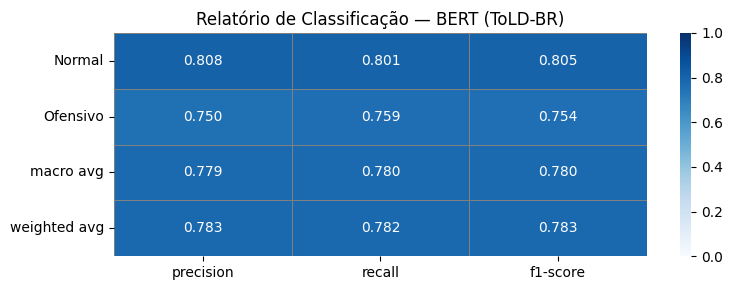

F1-score Macro: 0.7795


In [11]:
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_test = test_df['labels'].values

# Relatório de classificação como imagem
report_dict = classification_report(y_test, y_pred, target_names=['Normal', 'Ofensivo'], output_dict=True)
df_report = pd.DataFrame(report_dict).T.drop('accuracy', errors='ignore')

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    df_report[['precision', 'recall', 'f1-score']].astype(float),
    annot=True, fmt='.3f', cmap='Blues',
    linewidths=0.5, linecolor='gray',
    ax=ax, vmin=0, vmax=1
)
ax.set_title('Relatório de Classificação \u2014 BERT (ToLD-BR)')
plt.tight_layout()
plt.savefig('report_bert_toldbr.png', dpi=150, bbox_inches='tight')
plt.show()

f1_macro = report_dict['macro avg']['f1-score']
print(f'F1-score Macro: {f1_macro:.4f}')

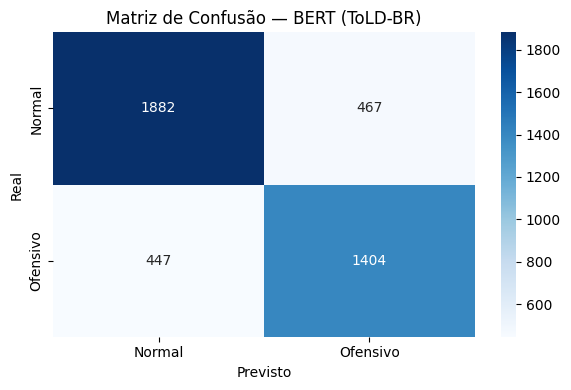

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ofensivo'],
            yticklabels=['Normal', 'Ofensivo'])
plt.title('Matriz de Confusão — BERT (ToLD-BR)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 11. Métricas por época

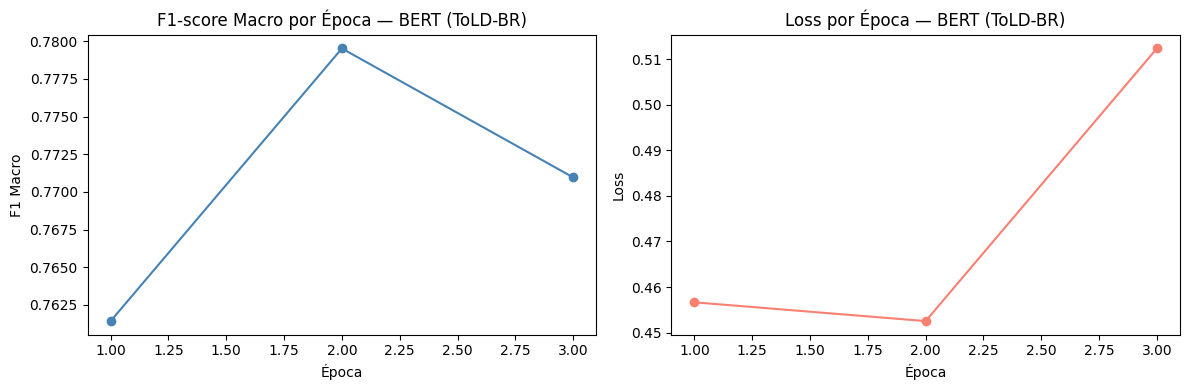

In [12]:
log_history = trainer.state.log_history
eval_entries = [e for e in log_history if 'eval_f1_macro' in e]

if eval_entries:
    epochs = [e['epoch'] for e in eval_entries]
    f1s = [e['eval_f1_macro'] for e in eval_entries]
    losses = [e['eval_loss'] for e in eval_entries]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, f1s, marker='o', color='steelblue')
    axes[0].set_title('F1-score Macro por Época — BERT (ToLD-BR)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('F1 Macro')

    axes[1].plot(epochs, losses, marker='o', color='salmon')
    axes[1].set_title('Loss por Época — BERT (ToLD-BR)')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()

In [14]:
# ANALISE_QUALITATIVA_PATCH
import pandas as _pd, numpy as _np, os as _os

# Textos de teste já disponíveis em test_df
_texts = test_df['text'].values

# Índices de FP e FN
_fp_idx = _np.where((y_test == 0) & (y_pred == 1))[0]
_fn_idx = _np.where((y_test == 1) & (y_pred == 0))[0]

_rng = _np.random.default_rng(42)
_fp_s = _rng.choice(_fp_idx, size=min(10, len(_fp_idx)), replace=False) if len(_fp_idx) else _np.array([], int)
_fn_s = _rng.choice(_fn_idx, size=min(10, len(_fn_idx)), replace=False) if len(_fn_idx) else _np.array([], int)

_rows = []
for _i in _fp_s:
    _rows.append({'modelo': 'BERTimbau', 'dataset': 'ToLD-BR',
                   'tipo': 'Falso Positivo', 'texto': _texts[_i],
                   'rotulo_real': int(y_test[_i]), 'predicao': int(y_pred[_i])})
for _i in _fn_s:
    _rows.append({'modelo': 'BERTimbau', 'dataset': 'ToLD-BR',
                   'tipo': 'Falso Negativo', 'texto': _texts[_i],
                   'rotulo_real': int(y_test[_i]), 'predicao': int(y_pred[_i])})

_csv = 'analisequalitativa.csv'
_df_new = _pd.DataFrame(_rows)
if _os.path.exists(_csv):
    _df_existing = _pd.read_csv(_csv)
    # Remove entradas anteriores do mesmo modelo/dataset antes de adicionar
    _df_existing = _df_existing[
        ~((_df_existing['modelo'] == 'BERTimbau') & (_df_existing['dataset'] == 'ToLD-BR'))
    ]
    _df_new = _pd.concat([_df_existing, _df_new], ignore_index=True)
_df_new.to_csv(_csv, index=False)

# Também expõe _texts para a célula de gráfico (se houver)
texts_qualitativa = _texts

print(f'Exportados {len(_fp_s)} FP e {len(_fn_s)} FN → {_csv}')
print(f'Total no arquivo: {len(_df_new)} linhas')

Exportados 10 FP e 10 FN → analisequalitativa.csv
Total no arquivo: 40 linhas


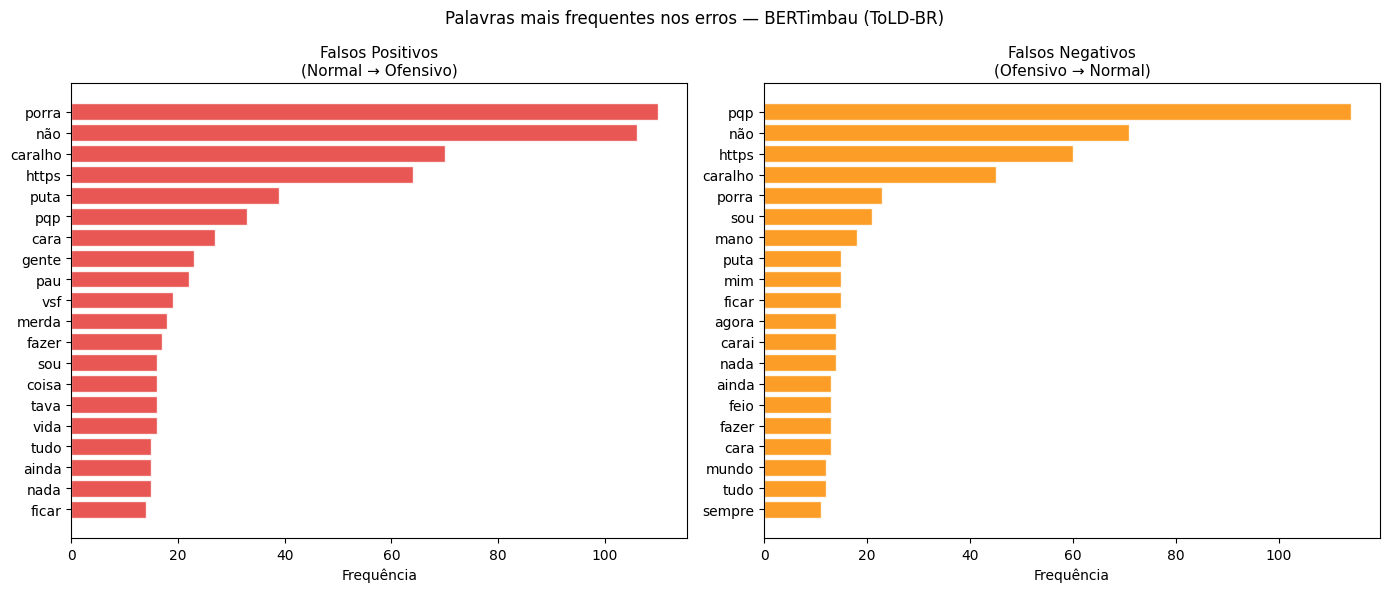

Figura salva: palavras_erros_bert_toldbr.png


In [15]:
# ANALISE_QUALITATIVA_PATCH_WORDS — gráfico de palavras (ToLD-BR)
import re as _re, matplotlib.pyplot as _plt, numpy as _np2
from collections import Counter as _Counter

STOPWORDS = {
    'de','a','o','que','e','do','da','em','um','para','é','com','uma','os','no',
    'se','na','por','mais','as','dos','como','mas','foi','ao','ele','das','tem',
    'à','seu','sua','ou','ser','quando','muito','há','nos','já','está','eu',
    'também','só','pelo','pela','até','isso','ela','entre','era','depois','sem',
    'mesmo','aos','ter','seus','quem','nas','me','esse','eles','estão','você',
    'tinha','foram','essa','num','nem','suas','meu','às','minha','têm','numa',
    'pelos','pelas','nesse','este','neste','rt','user','pra','vai','vou','aí',
    'lá','né','tá','tô','vc','vcs','pq','tb','tmb','mto','mta','kkk','kk',
}

def _top_words(texts, n=20):
    words = []
    for t in texts:
        toks = _re.findall(r'\b[a-záéíóúâêôãõç]{3,}\b', str(t).lower())
        words.extend([w for w in toks if w not in STOPWORDS])
    return _Counter(words).most_common(n)

_fp_texts = texts_qualitativa[(_np.array(y_test) == 0) & (_np.array(y_pred) == 1)]
_fn_texts = texts_qualitativa[(_np.array(y_test) == 1) & (_np.array(y_pred) == 0)]

_top_fp = _top_words(_fp_texts, n=20)
_top_fn = _top_words(_fn_texts, n=20)

_fig, (_ax1, _ax2) = _plt.subplots(1, 2, figsize=(14, 6))

if _top_fp:
    _w, _c = zip(*_top_fp)
    _ax1.barh(list(reversed(_w)), list(reversed(_c)), color='#E53935', alpha=0.85, edgecolor='white')
_ax1.set_title('Falsos Positivos\n(Normal → Ofensivo)', fontsize=11)
_ax1.set_xlabel('Frequência')

if _top_fn:
    _w, _c = zip(*_top_fn)
    _ax2.barh(list(reversed(_w)), list(reversed(_c)), color='#FB8C00', alpha=0.85, edgecolor='white')
_ax2.set_title('Falsos Negativos\n(Ofensivo → Normal)', fontsize=11)
_ax2.set_xlabel('Frequência')

_plt.suptitle('Palavras mais frequentes nos erros — BERTimbau (ToLD-BR)', fontsize=12)
_plt.tight_layout()
_fig_path = 'palavras_erros_bert_toldbr.png'
_plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
_plt.show()
print(f'Figura salva: {_fig_path}')